## Calibration by temparature scaling

### Imports

In [36]:
from transformers import AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm
from torch.utils.data import Dataset

import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

import torch
import sys

sys.path.append("../services/")
from index import Index

In [37]:
def retrieve_answer_token_index(tokens):
    for i in range(len(tokens) - 1, 0, -1):
        if tokens[i]["token"].isdigit():
            return i


def retrieve_reasoning_tokens_range(tokens):
    field1_text = '"short_chain_of_thoughts": "'
    field2_text = '"answer": "'

    start_index, end_index = -1, -1

    tmp_text = ""
    for i in range(len(tokens)):
        if field1_text in tmp_text:
            start_index = i
            break
        tmp_text += tokens[i]["token"]

    tmp_text = ""

    for i in range(len(tokens) - 1, 0, -1):
        tmp_text = tokens[i]["token"] + tmp_text
        if field2_text in tmp_text:
            end_index = i
            break

    return (start_index, end_index)

### Preparation

In [ ]:
torch.random.manual_seed(42)

dataset = load_dataset("TIGER-Lab/MMLU-Pro", split="test").select(range(5000))
index = Index("../index_data/qwen2.5-7B_launch5000_")
model_id = "Qwen/Qwen2.5-7B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

In [67]:
PAD_VAL = 0

VOCAB_SIZE = 20
split_val = len(index) // 2


class IndexDataset(Dataset):
    def __init__(
        self,
        index: Index,
        dataset: Dataset,
        split="train",
        load_all_data=False,
        device=torch.device("cpu"),
        train_split=0.5,
        val_split=0.7,
    ):
        self.index = index
        self.dataset = dataset
        self.split = split
        self.device = device

        if split == "train":
            self.indices = list(range(int(len(index) * train_split)))
        elif split == "val":
            self.indices = list(
                range(int(len(index) * train_split), int(len(index) * val_split))
            )
        else:
            self.indices = list(range(int(len(index) * val_split), len(index)))

        if load_all_data:
            self._load_data()

    def __len__(self):
        return len(self.indices) - 1

    def _load_data(self):
        self.data = self.process_elements(
            np.array(index.load_data(self.indices[0], self.indices[-1])),
            np.array(
                self.dataset.select(range(self.indices[0], self.indices[-1]))
            ),
        )

    def get(self, start=0, end=-1):
        if self.data:
            return {k: v[start:end] for k, v in self.data.items()}

        xs = np.array(
            [
                x
                for x in self.index.load_data(
                    self.indices[start], self.indices[end]
                )
            ]
        )
        ys = np.array(
            self.dataset.select(range(self.indices[start], self.indices[end]))
        )

        return self.process_elements(xs, ys)

    def process_elements(self, xs: np.array, ys: np.array):
        processed = {}

        allowed_ids = []
        for i, x in enumerate(xs):
            # Ignoring responses where answer token distribution doesn't have all 0-9 tokens
            log = x["logprobs"][retrieve_answer_token_index(x["logprobs"])]
            if (
                len(
                    set([str(x) for x in range(10)]).intersection(
                        set([x["token"] for x in log["top_logprobs"]])
                    )
                )
                < 10
            ):
                continue
            allowed_ids.append(i)

        xs = xs[allowed_ids]
        ys = ys[allowed_ids]

        logits = torch.zeros((len(xs), VOCAB_SIZE))
        targets = torch.zeros(len(ys), dtype=torch.long)

        for i, (x, y) in enumerate(zip(xs, ys)):
            answer_token_index = retrieve_answer_token_index(x["logprobs"])
            answer_top_logprobs_tokens = [
                v["token"]
                for v in x["logprobs"][answer_token_index]["top_logprobs"]
            ]
            answer_top_logprobs = torch.tensor(
                [
                    v["logprob"]
                    for v in x["logprobs"][answer_token_index]["top_logprobs"]
                ]
            )

            max_logprob = answer_top_logprobs.max()
            norm_top_logprobs = answer_top_logprobs - max_logprob

            logits[i] = norm_top_logprobs
            targets[i] = torch.tensor(
                answer_top_logprobs_tokens.index(str(y["answer_index"])),
                dtype=torch.long,
            )

        processed["logits"] = logits
        processed["targets"] = targets

        return processed

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train = IndexDataset(
    index, dataset, split="train", load_all_data=True, device=device
)
val = IndexDataset(
    index, dataset, split="val", load_all_data=True, device=device
)
test = IndexDataset(
    index, dataset, split="test", load_all_data=True, device=device
)

In [69]:
val_data = val.get()
test_data = test.get()

### Temperature scaling

In [70]:
# Module which will learn temperature value


class TemperatureScaling(nn.Module):
    def __init__(self, device=device):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1, device=device))

    def forward(self, logits):
        return torch.div(logits, self.temperature)

    def scale(self, logits):
        logits = self.forward(logits)
        return torch.softmax(logits, dim=1)

In [71]:
# Function to fit temperature value


def fit_temperature_scaling(
    train_data,
    test_data=None,
    lr_max=1e-2,
    lr_min=1e-4,
    batch_size=8,
    epochs=3,
    plot_interval=3,
):
    temperature_model = TemperatureScaling(device)
    optimizer = torch.optim.Adam([temperature_model.temperature], lr_max)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, len(train_data) // batch_size, lr_min
    )

    train_losses = []
    test_losses = []
    iterations = []

    iteration_counter = 0

    for _ in tqdm(range(epochs)):
        for start in range(0, len(train_data) - batch_size, batch_size):
            batch_data = train_data.get(start, start + batch_size)
            if not batch_data:
                continue

            optimizer.zero_grad()
            batch_logits = batch_data["logits"].view(-1, VOCAB_SIZE).to(device)
            batch_labels = batch_data["targets"].view(-1).to(device)
            train_scaled_logits = temperature_model(batch_logits)
            train_loss = torch.nn.functional.cross_entropy(
                train_scaled_logits, batch_labels, ignore_index=PAD_VAL
            )
            train_loss.backward()
            optimizer.step()
            scheduler.step()

            if (
                test_data is not None
                and iteration_counter % plot_interval == 0
            ):
                train_loss = train_loss.item()
                train_losses.append(train_loss)

                test_batch = test_data.get(0, min(batch_size, len(test_data)))
                if test_batch:
                    test_logits = (
                        test_batch["logits"].view(-1, VOCAB_SIZE).to(device)
                    )
                    test_labels = test_batch["targets"].view(-1).to(device)
                    with torch.no_grad():
                        test_scaled_logits = temperature_model(test_logits)
                        test_loss = torch.nn.functional.cross_entropy(
                            test_scaled_logits,
                            test_labels,
                            ignore_index=PAD_VAL,
                        )
                        test_losses.append(test_loss.item())
                    iterations.append(iteration_counter)

            iteration_counter += 1

    if len(iterations) > 0:
        plt.figure(figsize=(10, 6))
        plt.plot(iterations, train_losses, label="Train Loss", marker="o")
        if len(test_losses) > 0:
            plt.plot(iterations, test_losses, label="Test Loss", marker="s")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss over Iterations")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return temperature_model.temperature.item()

### Calibration

In [72]:
def calculate_ece_adaptive_bins(probs, targets, n_bins=10, verbose=False):
    token_probs = probs.max(dim=1).values
    accuracies = probs.argmax(dim=-1) == targets

    sorted_indices = torch.argsort(token_probs)
    sorted_probs = token_probs[sorted_indices]
    sorted_accuracies = accuracies[sorted_indices]

    n_samples = len(sorted_probs)
    bin_size = n_samples // n_bins

    ece = torch.zeros(1).to(device)

    if verbose:
        bin_avg_confidences = []
        bin_accuracies_list = []
        bin_conf_min = []
        bin_conf_max = []

    for i in range(n_bins):
        start_idx = i * bin_size
        if i == n_bins - 1:
            end_idx = n_samples
        else:
            end_idx = (i + 1) * bin_size

        if end_idx > start_idx:
            bin_probs = sorted_probs[start_idx:end_idx]
            bin_accuracies = sorted_accuracies[start_idx:end_idx]

            prop_in_bin = (end_idx - start_idx) / n_samples

            if prop_in_bin > 0:
                accuracy_in_bin = bin_accuracies.float().mean()
                avg_confidence_in_bin = bin_probs.mean()
                ece += (
                    torch.abs(avg_confidence_in_bin - accuracy_in_bin)
                    * prop_in_bin
                )

            if verbose:
                bin_avg_confidences.append(
                    avg_confidence_in_bin.detach().cpu()
                )
                bin_accuracies_list.append(accuracy_in_bin.detach().cpu())
                bin_conf_min.append(bin_probs.min().detach().cpu())
                bin_conf_max.append(bin_probs.max().detach().cpu())

    if verbose:
        bin_avg_confidences = torch.stack(bin_avg_confidences).numpy()
        bin_accuracies_list = torch.stack(bin_accuracies_list).numpy()
        bin_conf_min = torch.stack(bin_conf_min).numpy()
        bin_conf_max = torch.stack(bin_conf_max).numpy()

        plt.figure(figsize=(6, 6))

        # Perfect calibration
        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            color="gray",
            label="Perfect calibration",
        )

        # Reliability curve (points)
        plt.plot(
            bin_avg_confidences,
            bin_accuracies_list,
            marker="o",
            linewidth=2,
            label="Model (adaptive bins)",
        )

        # Shaded bin coverage
        for i in range(len(bin_accuracies_list)):
            plt.fill_between(
                [
                    bin_conf_min[i] if i > 0 else 0,
                    bin_conf_max[i] if i < len(bin_accuracies_list) - 1 else 1,
                ],
                0,
                bin_accuracies_list[i] + 0.005,
                alpha=0.4,
            )

        plt.xlabel("Confidence")
        plt.ylabel("Accuracy")
        plt.title("Reliability Diagram with Adaptive Bin Coverage")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return ece.item()

### FInding the best temperature on validation data


Trial 1/10: lr_max=0.100000, lr_min=0.000500, batch_size=16, epochs=3


100%|██████████| 3/3 [00:00<00:00,  4.35it/s]


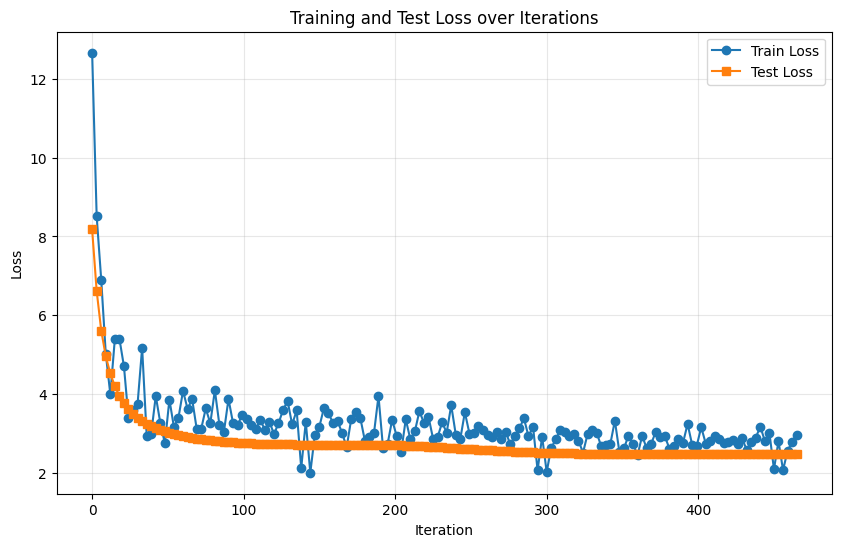

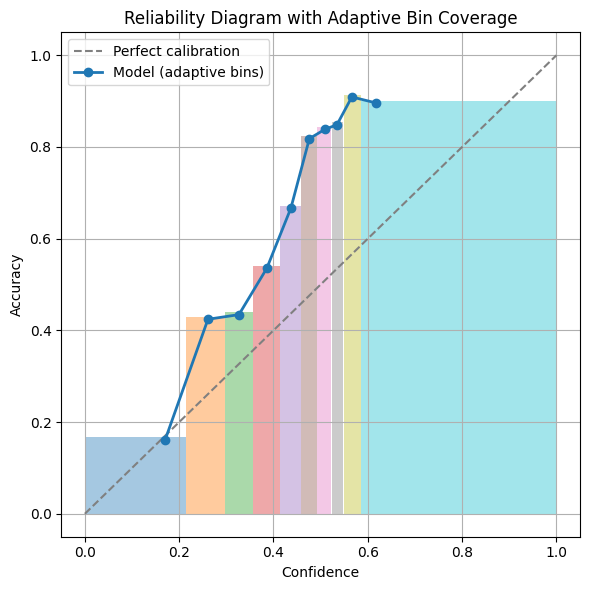

Temperature: 6.4855, ECE: 0.227031

Trial 2/10: lr_max=0.050000, lr_min=0.001000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:00<00:00,  5.17it/s]


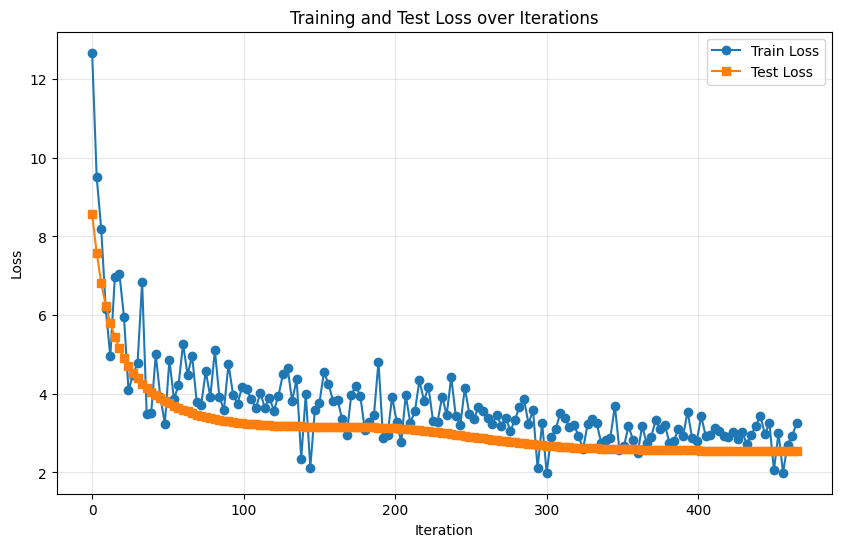

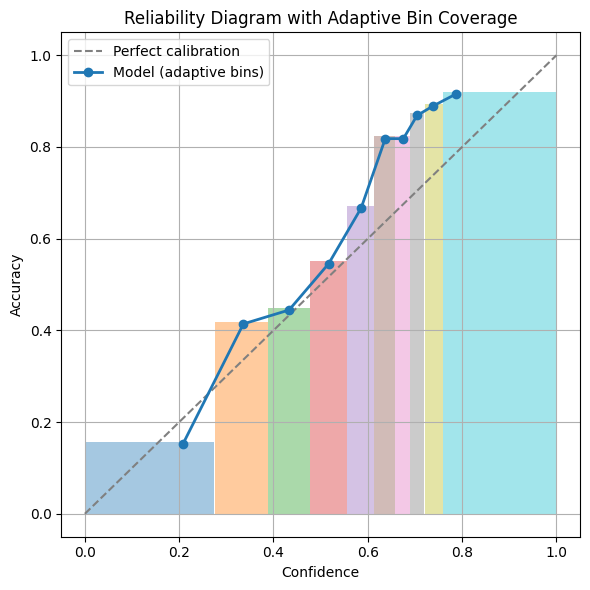

Temperature: 5.1611, ECE: 0.102493

Trial 3/10: lr_max=0.005000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:00<00:00,  4.37it/s]


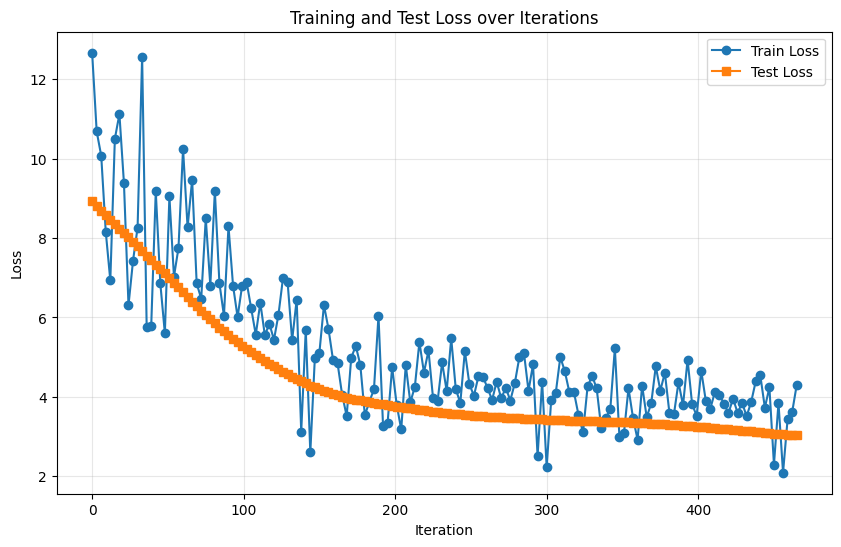

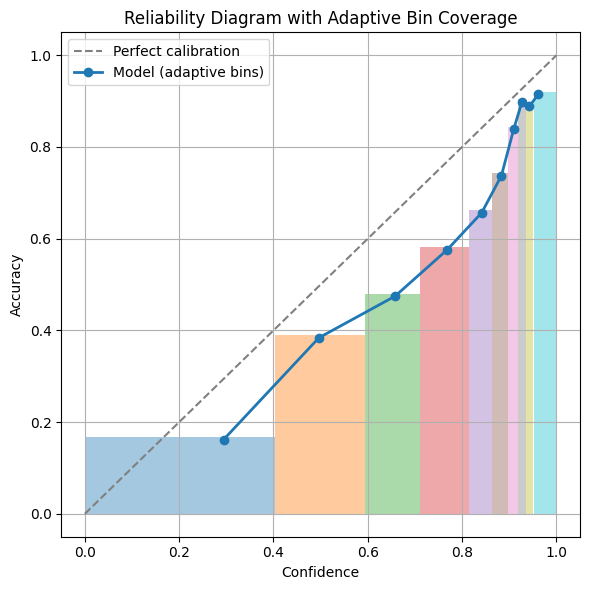

Temperature: 3.4582, ECE: 0.114647

Trial 4/10: lr_max=0.020000, lr_min=0.001000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:00<00:00,  4.87it/s]


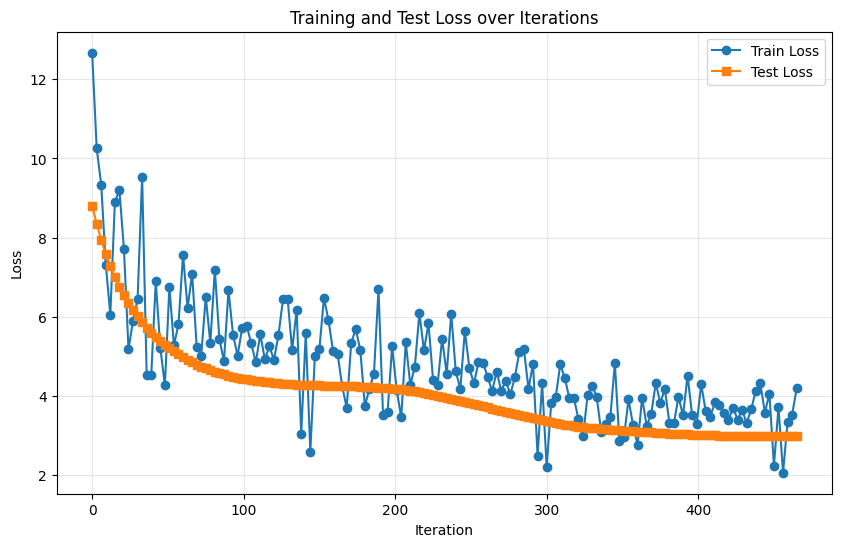

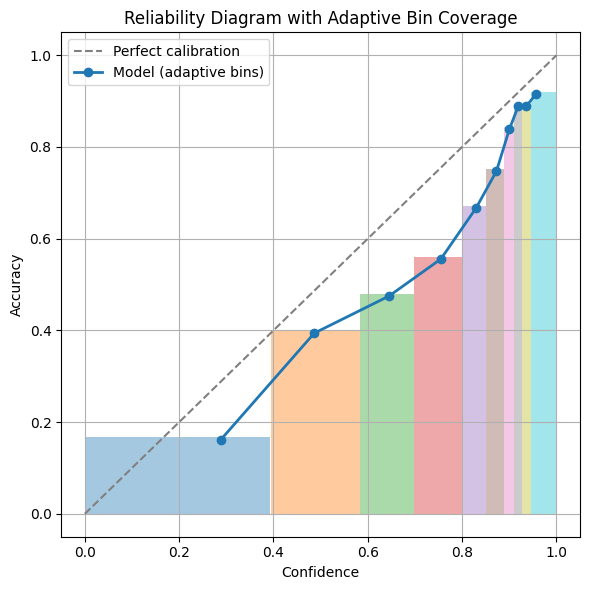

Temperature: 3.5404, ECE: 0.105276

Trial 5/10: lr_max=0.100000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:00<00:00,  4.00it/s]


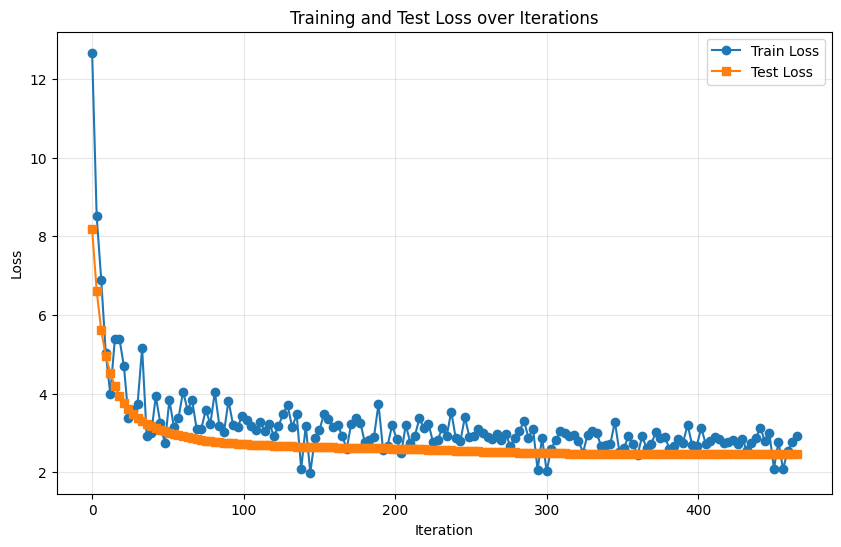

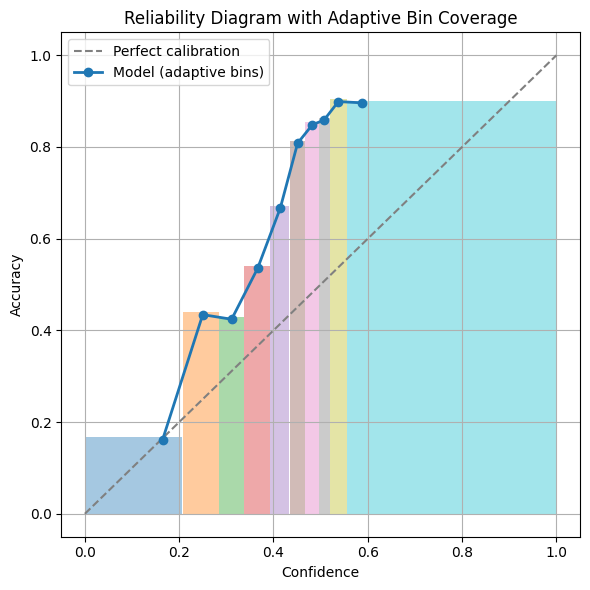

Temperature: 6.7423, ECE: 0.247136

Trial 6/10: lr_max=0.020000, lr_min=0.000100, batch_size=16, epochs=3


100%|██████████| 3/3 [00:00<00:00,  4.78it/s]


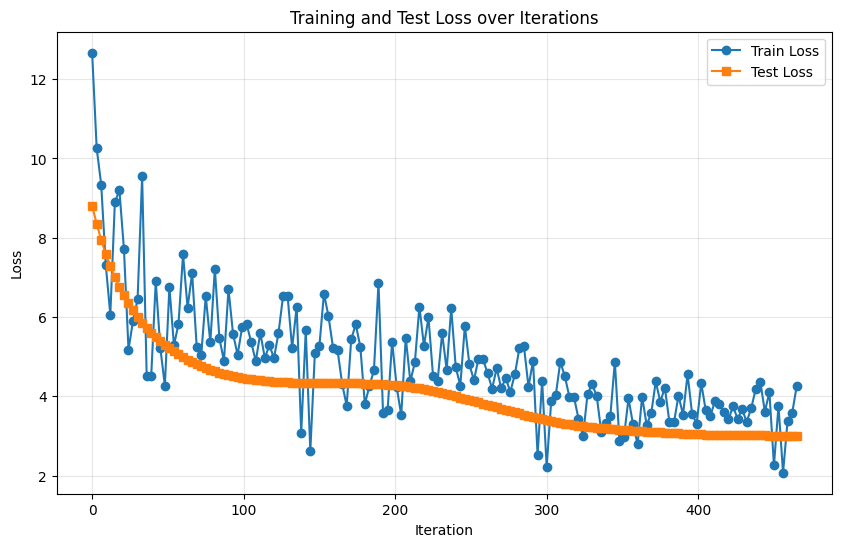

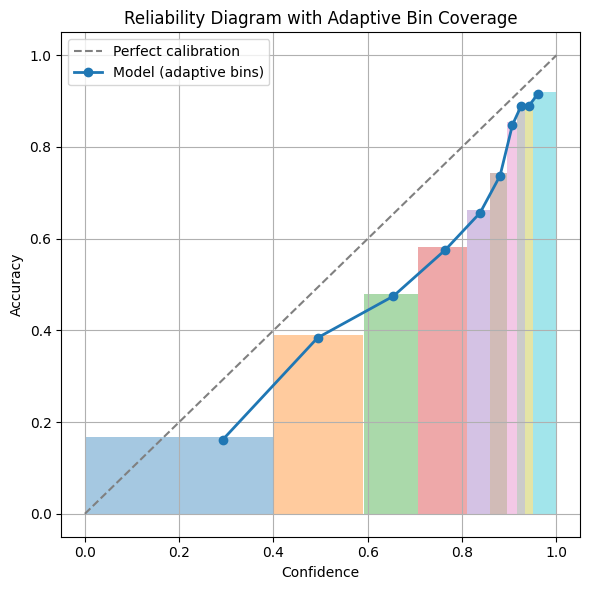

Temperature: 3.4811, ECE: 0.112062

Trial 7/10: lr_max=0.100000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:00<00:00,  4.47it/s]


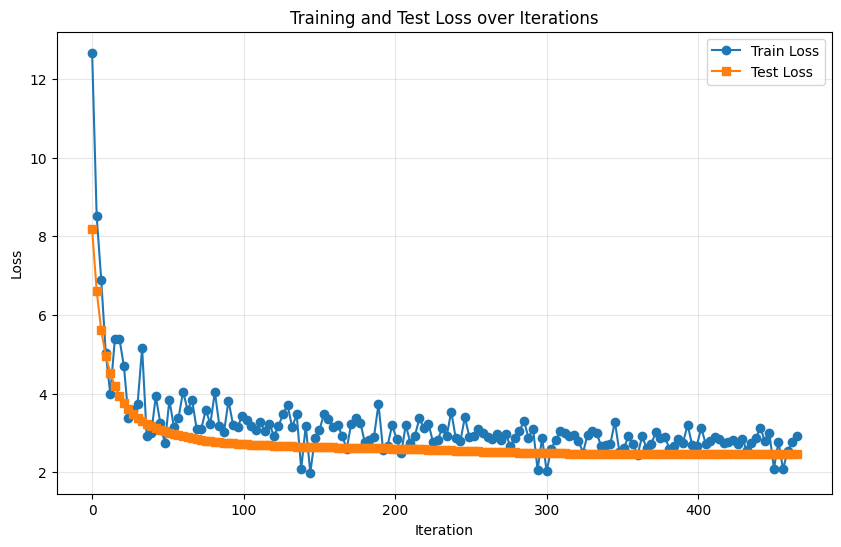

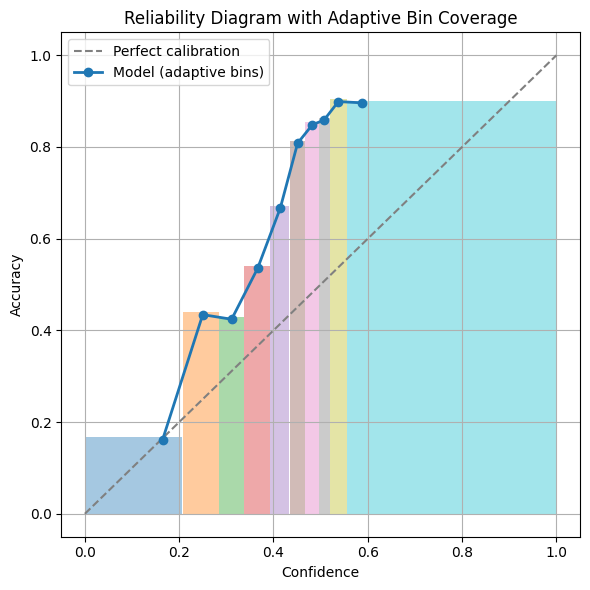

Temperature: 6.7423, ECE: 0.247136

Trial 8/10: lr_max=0.020000, lr_min=0.000100, batch_size=16, epochs=3


100%|██████████| 3/3 [00:03<00:00,  1.19s/it]


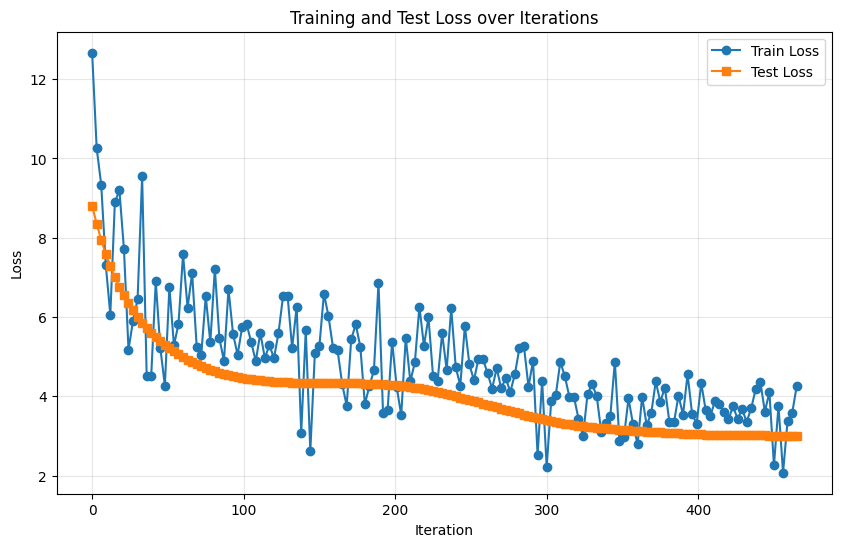

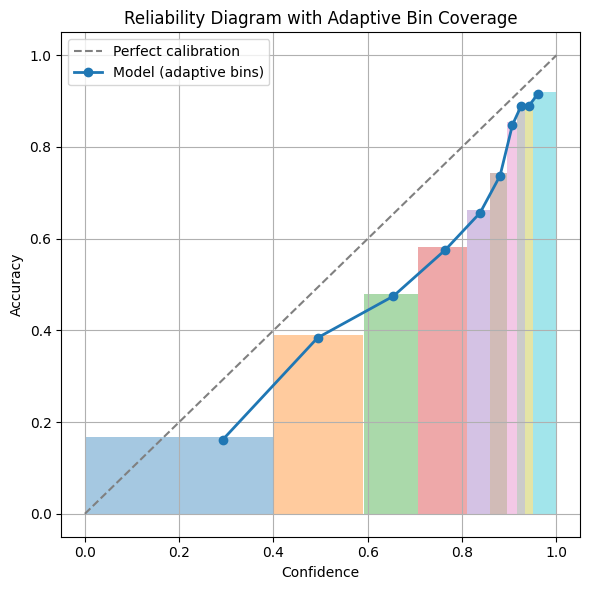

Temperature: 3.4811, ECE: 0.112062

Trial 9/10: lr_max=0.001000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:00<00:00,  4.55it/s]


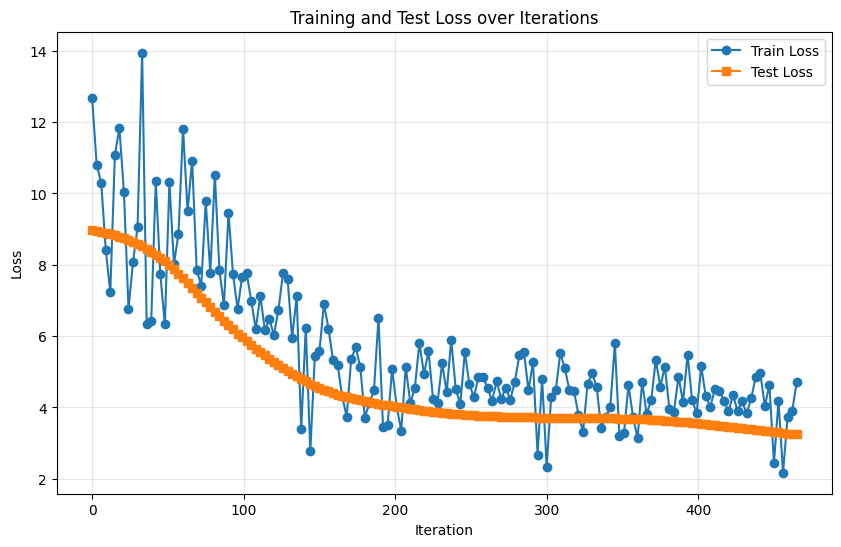

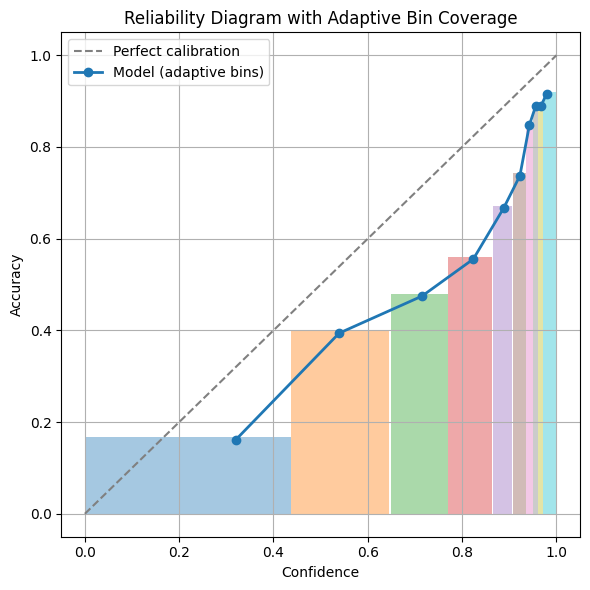

Temperature: 3.1158, ECE: 0.151594

Trial 10/10: lr_max=0.020000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:00<00:00,  4.52it/s]


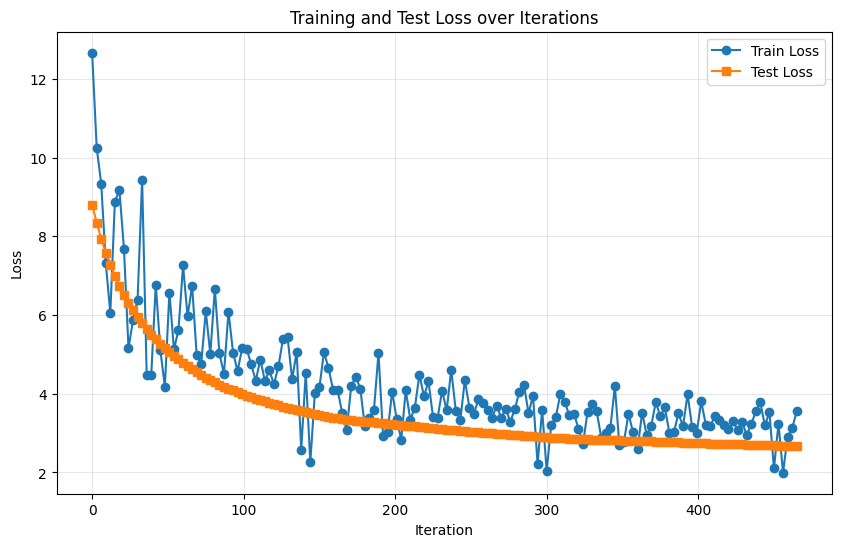

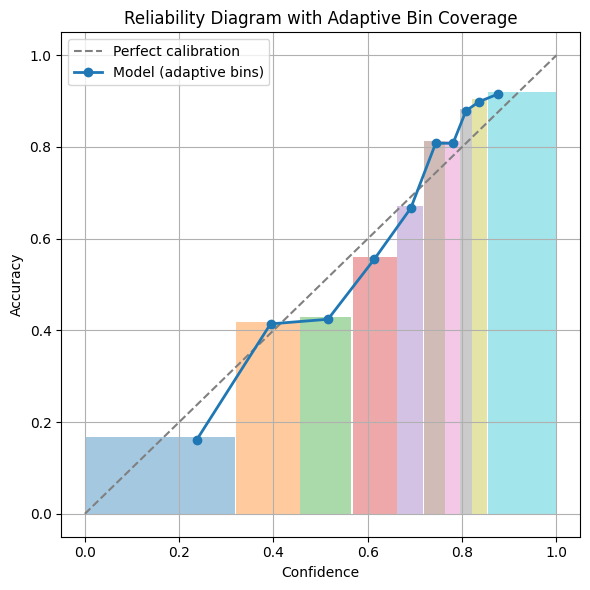

Temperature: 4.4360, ECE: 0.053378

Best ECE on: 0.053378
Best parameters: {'lr_max': np.float64(0.02), 'lr_min': np.float64(0.02), 'batch_size': 16, 'epochs': 3}
Best temperature: 4.4360


In [73]:
TRIALS = 10

results = []

for trial in range(TRIALS):
    lr_max = np.random.choice([1e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1])
    lr_min = np.random.choice([1e-4, 5e-4, 1e-3, 2e-2])
    batch_size = 16
    epochs = 3

    print(
        f"\nTrial {trial + 1}/{TRIALS}: lr_max={lr_max:.6f}, lr_min={lr_min:.6f}, batch_size={batch_size}, epochs={epochs}"
    )

    temperature = fit_temperature_scaling(
        train,
        val,
        lr_max=lr_max,
        lr_min=lr_min,
        batch_size=batch_size,
        epochs=epochs,
    )

    calibrated_logits = [torch.div(x, temperature) for x in val_data["logits"]]
    calibrated_probs = torch.stack(
        [torch.softmax(x, dim=0) for x in calibrated_logits]
    )
    ece = calculate_ece_adaptive_bins(
        calibrated_probs, val_data["targets"], verbose=True
    )

    results.append(
        {
            "params": {
                "lr_max": lr_max,
                "lr_min": lr_min,
                "batch_size": batch_size,
                "epochs": epochs,
            },
            "temperature": temperature,
            "ece": ece,
        }
    )

    print(f"Temperature: {temperature:.4f}, ECE: {ece:.6f}")

best_result = min(results, key=lambda x: x["ece"])

print("\n" + "=" * 60)
print(f"Best ECE on: {best_result['ece']:.6f}")
print(f"Best parameters: {best_result['params']}")
print(f"Best temperature: {best_result['temperature']:.4f}")

### Results

In [74]:
temperature = best_result["temperature"]

calibrated_test_answers_logits = [
    torch.div(x, temperature) for x in test_data["logits"]
]

not_calibrated_test_answers_probs = torch.stack(
    [torch.softmax(x, dim=0) for x in test_data["logits"]]
)
calibrated_test_answers_probs = torch.stack(
    [torch.softmax(x, dim=0) for x in calibrated_test_answers_logits]
)

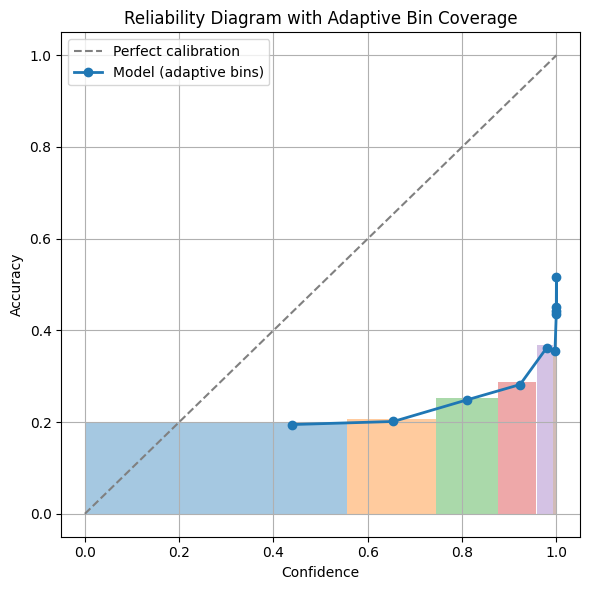

ECE on NON calibrated answer (test data): 0.5312900543212891


In [75]:
print(
    f"ECE on NON calibrated answer (test data): {calculate_ece_adaptive_bins(not_calibrated_test_answers_probs, test_data['targets'], verbose=True)}"
)

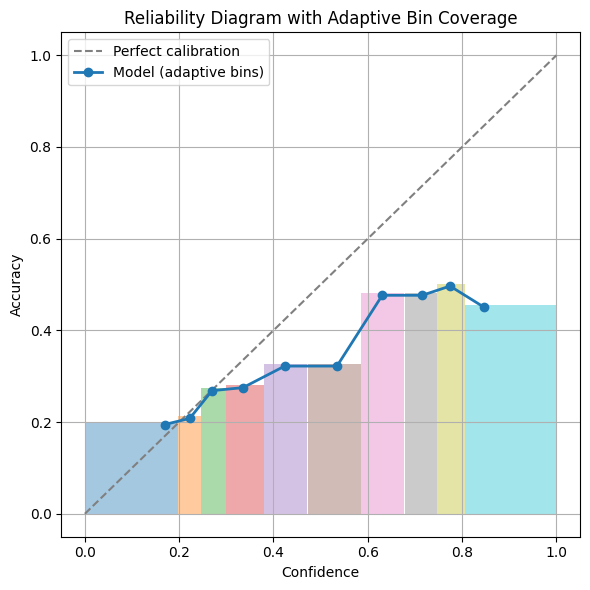

ECE on calibrated answer (test data): 0.148569256067276


In [76]:
print(
    f"ECE on calibrated answer (test data): {calculate_ece_adaptive_bins(calibrated_test_answers_probs, test_data['targets'], verbose=True)}"
)

tensor([9.9999e-01, 9.7719e-06, 1.0481e-06, 3.7857e-07, 3.7448e-07, 3.2184e-07,
        1.3503e-07, 1.2140e-07, 4.5092e-08, 3.6387e-08, 1.0592e-09, 1.4463e-10,
        9.6831e-11, 9.5656e-11, 8.6693e-11, 8.1734e-11, 8.1263e-11, 7.6057e-11,
        7.0460e-11, 5.9026e-11])


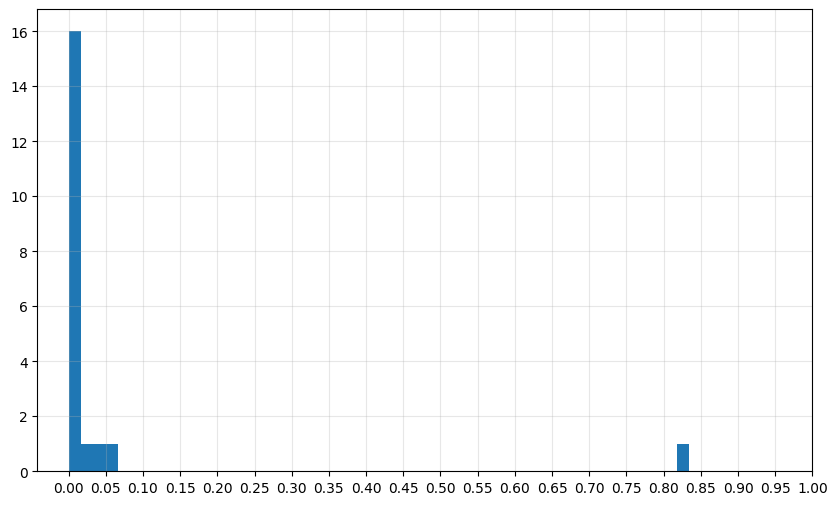

In [77]:
plt.figure(figsize=(10, 6))
plt.hist(not_calibrated_test_answers_probs[1], bins=50)
plt.xticks(np.arange(0.0, 1.001, 5e-2))
plt.grid(True, alpha=0.3)
print(not_calibrated_test_answers_probs[8])
plt.show()

tensor([0.7238, 0.0537, 0.0325, 0.0258, 0.0258, 0.0249, 0.0205, 0.0200, 0.0160,
        0.0152, 0.0069, 0.0044, 0.0040, 0.0040, 0.0039, 0.0039, 0.0038, 0.0038,
        0.0037, 0.0036])


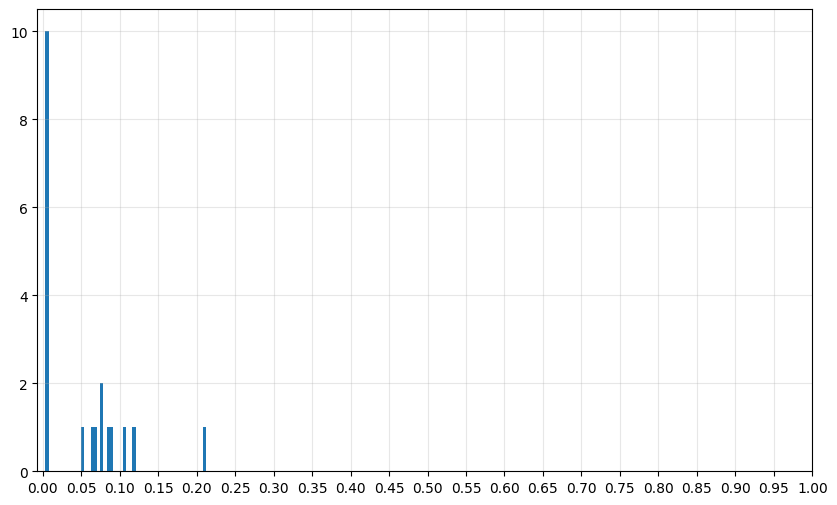

In [78]:
plt.figure(figsize=(10, 6))
plt.hist(calibrated_test_answers_probs[1], bins=50)
plt.xticks(np.arange(0.0, 1.001, 5e-2))
plt.grid(True, alpha=0.3)
print(calibrated_test_answers_probs[8])
plt.show()

In [79]:
accuracies = (
    not_calibrated_test_answers_probs.argmax(dim=-1) == test_data["targets"]
).to(torch.float)
print(f"Accuracy on NON calibrated answer: {torch.mean(accuracies).item()}")

Accuracy on NON calibrated answer: 0.3491957187652588


In [80]:
accuracies = (
    calibrated_test_answers_probs.argmax(dim=-1) == test_data["targets"]
).to(torch.float)
print(f"Accuracy on calibrated answer: {torch.mean(accuracies).item()}")

Accuracy on calibrated answer: 0.3491957187652588
